In [2]:
import warnings
from itertools import product
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error

warnings.filterwarnings("ignore")

In [3]:
import os
DATA_PATH = os.environ.get(
    "MONETARY_DATA_PATH", os.path.join("..", "data", "Monetary_transmission_data_III.xlsx")
)
FEATURE_COLS = ["CPI", "EXR", "M2b", "RSV", "BRNT"]
TARGET_COLS = ["CPI", "EXR"]
TEST_FRAC = 0.15
MIN_TEST = 4
P_RANGE = range(0, 3)
D_RANGE = range(0, 2)
Q_RANGE = range(0, 3)

In [4]:
def load_data(path: str) -> pd.DataFrame:
    """Load raw Excel data and enforce a sorted monthly DatetimeIndex."""
    df = pd.read_excel(path, parse_dates=["DATE"])
    return df.sort_values("DATE").set_index("DATE").asfreq("MS")


df = load_data(DATA_PATH)[FEATURE_COLS]
df.head()

,CPI,EXR,M2b,RSV,BRNT
DATE,,,,,
2003-01-01,49.718237,96.76790,629492.928632,2.180175e+09,30.808696
2003-02-01,49.166690,96.86147,635737.068991,2.231537e+09,32.662500
2003-03-01,48.031996,96.93052,643063.430052,2.185916e+09,30.168095
2003-04-01,47.648499,96.98083,648591.184385,2.401949e+09,25.035000
2003-05-01,48.783192,97.21280,651250.316110,2.370521e+09,25.714545


In [5]:
# Same structural-break partition as the VAR/VECM and neural-net notebooks, so all
# five models are compared on identical windows. "W5" is the full, unsegmented series.
BREAK_DATES = pd.to_datetime(["2008-06-01", "2016-10-01", "2022-03-01"])
EDGES = [df.index.min(), *BREAK_DATES, df.index.max() + pd.DateOffset(days=1)]

WINDOWS = {f"W{i + 1}": (EDGES[i], EDGES[i + 1] - pd.DateOffset(days=1)) for i in range(len(EDGES) - 1)}
WINDOWS["W5"] = (df.index.min(), df.index.max())

for label, (start, end) in WINDOWS.items():
    print(f"{label}: {start.date()} -> {end.date()} ({len(df.loc[start:end])} months)")

W1: 2003-01-01 -> 2008-05-31 (65 months)
W2: 2008-06-01 -> 2016-09-30 (100 months)
W3: 2016-10-01 -> 2022-02-28 (65 months)
W4: 2022-03-01 -> 2025-10-01 (44 months)
W5: 2003-01-01 -> 2025-10-01 (274 months)


In [6]:
def select_order(series: pd.Series) -> tuple:
    """Grid-search ARIMA(p, d, q) by AIC on a single series."""
    best_aic, best_order = np.inf, (1, 1, 0)
    for order in product(P_RANGE, D_RANGE, Q_RANGE):
        try:
            aic = ARIMA(series, order=order).fit().aic
        except Exception:
            continue
        if aic < best_aic:
            best_aic, best_order = aic, order
    return best_order


def fit_forecast_series(series: pd.Series, test_size: int) -> tuple:
    """Select the AIC-optimal order on train, forecast the test horizon."""
    train, test = series.iloc[:-test_size], series.iloc[-test_size:]
    order = select_order(train)
    fitted = ARIMA(train, order=order).fit()
    forecast = fitted.forecast(steps=test_size)
    return forecast, test, order

In [7]:
def run_window_pipeline(df_window: pd.DataFrame) -> dict:
    """Fit and evaluate one ARIMA model per target series within a structural-break window."""
    test_size = max(int(len(df_window) * TEST_FRAC), MIN_TEST)
    window_result = {}
    for col in TARGET_COLS:
        forecast, actual, order = fit_forecast_series(df_window[col], test_size)
        window_result[col] = {
            "order": order,
            "forecast": forecast,
            "actual": actual,
            "RMSE": np.sqrt(mean_squared_error(actual, forecast)),
            "MAE": mean_absolute_error(actual, forecast),
        }
    return window_result


results = {}
for label, (start, end) in WINDOWS.items():
    df_w = df.loc[start:end]
    results[label] = run_window_pipeline(df_w)
    print(f"{label}: n={len(df_w)}")
    for col in TARGET_COLS:
        r = results[label][col]
        print(f"  {col}: order={r['order']} RMSE={r['RMSE']:.4f} MAE={r['MAE']:.4f}")

W1: n=65
  CPI: order=(1, 1, 0) RMSE=8.6187 MAE=7.3312
  EXR: order=(0, 1, 1) RMSE=3.4391 MAE=3.1369
W2: n=100
  CPI: order=(2, 1, 2) RMSE=4.2849 MAE=3.5954
  EXR: order=(1, 1, 0) RMSE=9.0520 MAE=8.2943
W3: n=65
  CPI: order=(2, 1, 2) RMSE=15.2640 MAE=11.6650
  EXR: order=(1, 1, 0) RMSE=0.6432 MAE=0.5837
W4: n=44
  CPI: order=(1, 1, 0) RMSE=5.1161 MAE=5.0124
  EXR: order=(1, 1, 0) RMSE=2.4349 MAE=2.3589
W5: n=274
  CPI: order=(1, 1, 1) RMSE=17.2782 MAE=13.9772
  EXR: order=(2, 1, 0) RMSE=39.3133 MAE=35.7643


In [8]:
# Selected ARIMA order and held-out test error per window/target.
summary_df = pd.DataFrame({
    (label, col): {"order": r[col]["order"], "RMSE": r[col]["RMSE"], "MAE": r[col]["MAE"]}
    for label, r in results.items() for col in TARGET_COLS
}).T
summary_df.index.names = ["window", "target"]
summary_df

order       RMSE        MAE
window target                                 
W1     CPI     (1, 1, 0)   8.618671    7.33121
       EXR     (0, 1, 1)   3.439074   3.136887
W2     CPI     (2, 1, 2)     4.2849   3.595427
       EXR     (1, 1, 0)   9.051966   8.294268
W3     CPI     (2, 1, 2)  15.264003  11.664974
       EXR     (1, 1, 0)    0.64318   0.583735
W4     CPI     (1, 1, 0)   5.116118   5.012427
       EXR     (1, 1, 0)   2.434923    2.35893
W5     CPI     (1, 1, 1)  17.278173  13.977156
       EXR     (2, 1, 0)  39.313257  35.764311

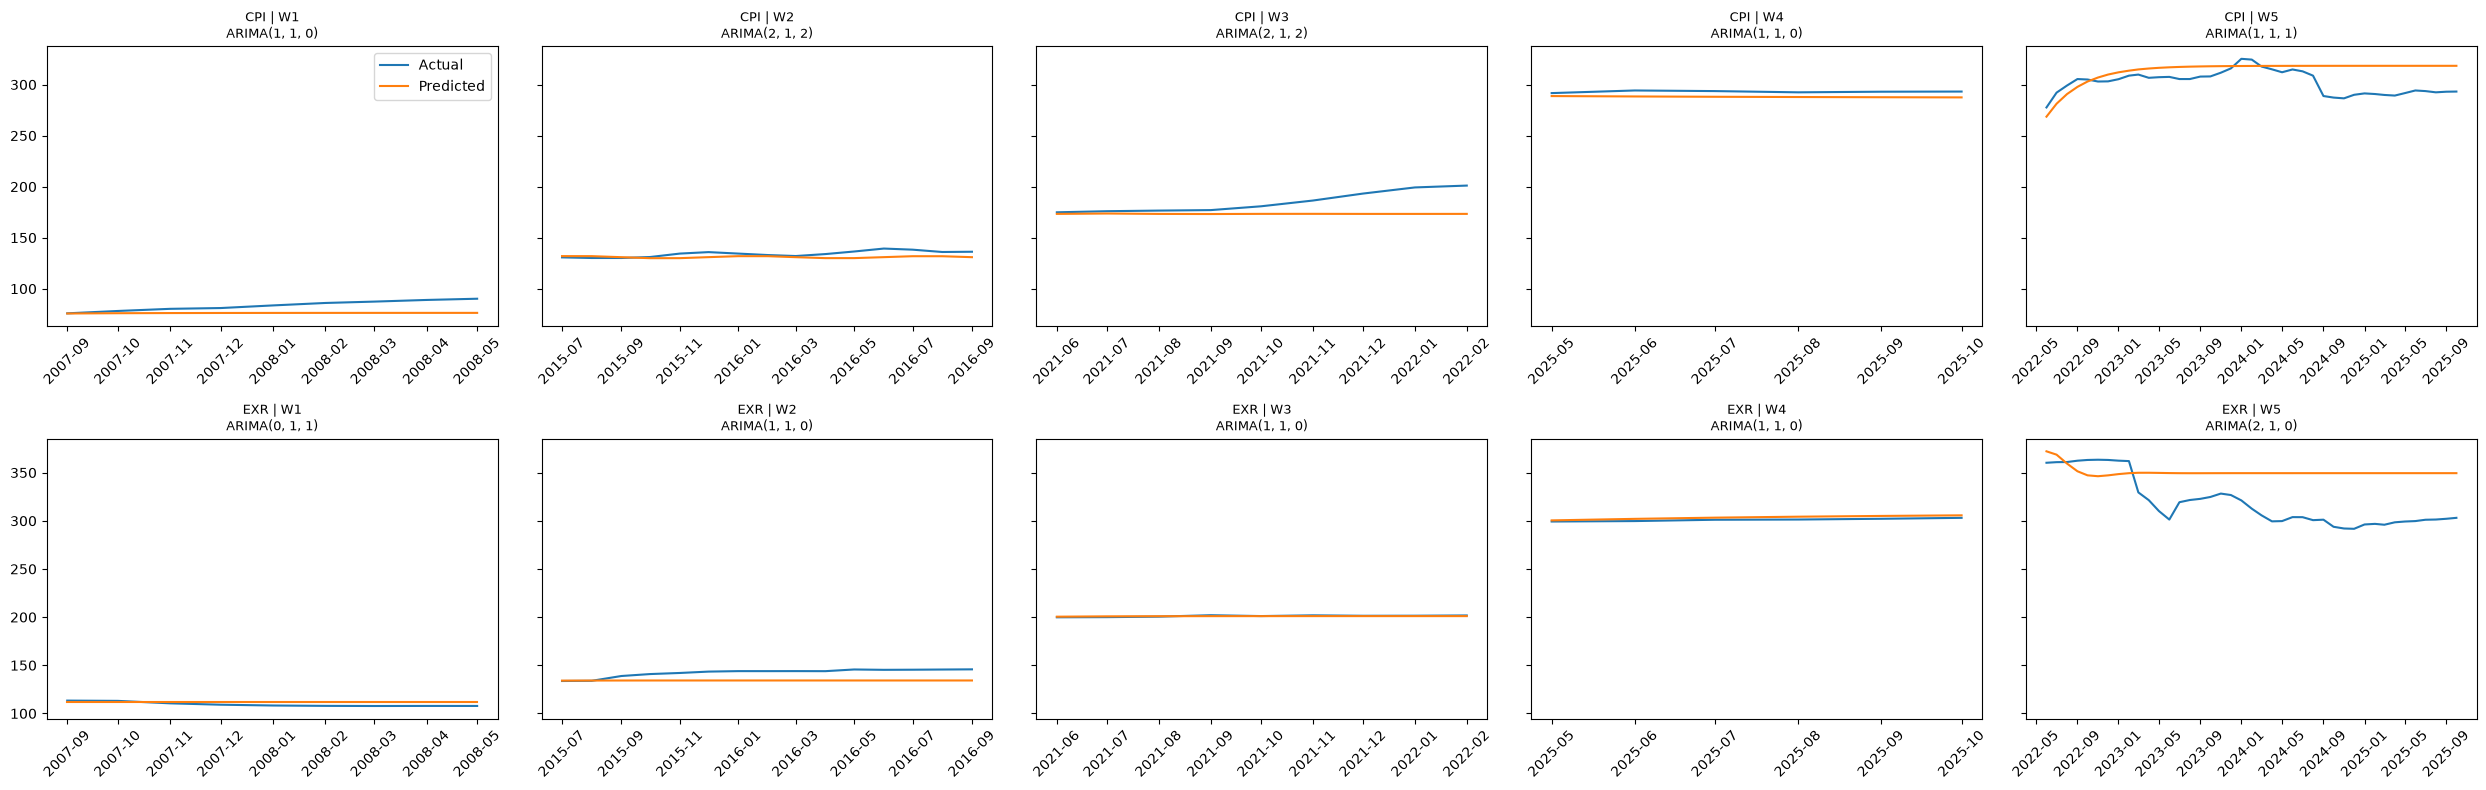

In [9]:
fig, axes = plt.subplots(len(TARGET_COLS), len(WINDOWS), figsize=(5 * len(WINDOWS), 4 * len(TARGET_COLS)), sharey="row")
for col_idx, target in enumerate(TARGET_COLS):
    for win_idx, (label, r) in enumerate(results.items()):
        ax = axes[col_idx, win_idx]
        actual, forecast = r[target]["actual"], r[target]["forecast"]
        ax.plot(actual.index, actual, label="Actual")
        ax.plot(actual.index, forecast, label="Predicted")
        ax.set_title(f"{target} | {label}\nARIMA{r[target]['order']}", fontsize=9)
        ax.tick_params(axis="x", labelrotation=45)
axes[0, 0].legend()
plt.tight_layout()
plt.show()

In [10]:
os.makedirs("../results", exist_ok=True)
# Standardized long-format export consumed by the model-comparison pipeline.
export_rows = [
    {"window": label, "target": col, "RMSE": r[col]["RMSE"], "MAE": r[col]["MAE"]}
    for label, r in results.items() for col in TARGET_COLS
]
pd.DataFrame(export_rows).to_csv(f"../results/metrics_arima.csv", index=False)

In [11]:
# Raw test-set predictions, consumed by the ensemble hybrid notebook.
pred_rows = [
    {"window": label, "target": col, "date": date, "actual": actual, "predicted": predicted}
    for label, r in results.items()
    for col in TARGET_COLS
    for date, actual, predicted in zip(r[col]["actual"].index, r[col]["actual"], r[col]["forecast"])
]
pd.DataFrame(pred_rows).to_csv("../results/predictions_arima.csv", index=False)